# Temperature Prediction

## Objective
Predict the **temperature** based on humidity data.


## Dataset Overview
The dataset contains hourly or daily readings of humidity and temperature.


## Workflow
1. Load the dataset  
2. Explore and clean the data  
3. Train a regression model  
4. Evaluate predictions


In [12]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [13]:
# Load the dataset
df = pd.read_csv("humidity.csv")
df.info()
df.head()


<class 'pandas.DataFrame'>
RangeIndex: 701548 entries, 0 to 701547
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   sensor_id    701548 non-null  int64  
 1   lat          701548 non-null  float64
 2   lon          701548 non-null  float64
 3   pressure     701548 non-null  float64
 4   temperature  701548 non-null  float64
 5   humidity     701548 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 32.1 MB


,sensor_id,lat,lon,pressure,temperature,humidity
0,2266,42.738,23.272,95270.27,23.46,62.48
1,2292,42.663,23.273,94355.83,23.06,59.46
2,3096,42.700,23.360,95155.81,26.53,44.38
3,3428,42.624,23.406,94679.57,28.34,38.28
4,3472,42.669,23.318,94327.88,26.31,46.37


## Exploratory Data Analysis


In [14]:
# Check for missing values
df.isnull().sum()
# Display summary statistics
df.describe()


,sensor_id,lat,lon,pressure,temperature,humidity
count,701548.000000,701548.000000,701548.000000,701548.000000,701548.000000,701548.000000
mean,2835.419842,42.679722,23.333739,94965.292500,24.754990,48.348949
std,798.018890,0.025568,0.039365,2577.210945,14.013001,20.907247
min,1764.000000,42.622000,23.240000,0.000000,-145.120000,0.000000
25%,2224.000000,42.665000,23.310000,94528.017500,20.630000,34.140000
50%,2323.000000,42.685000,23.332000,95005.480000,24.780000,48.350000
75%,3474.000000,42.694000,23.360000,95405.132500,29.870000,62.940000
max,4661.000000,42.738000,23.419000,164926.750000,61.170000,100.000000


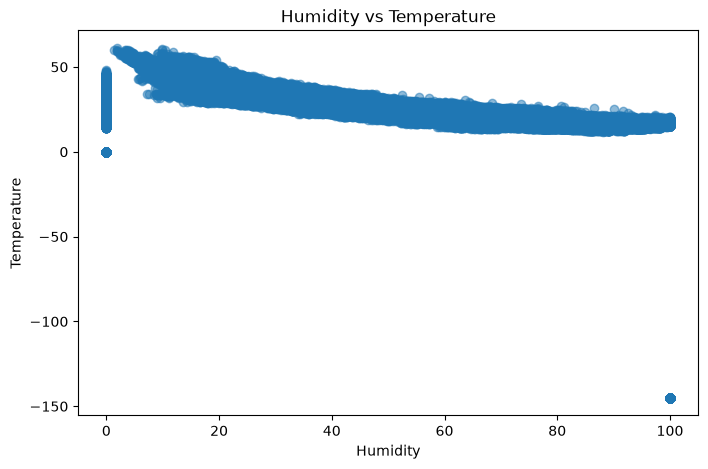

In [15]:
# Scatter plot to observe relationship
plt.figure(figsize=(8,5))
plt.scatter(df["humidity"], df["temperature"], alpha=0.5)
plt.xlabel("Humidity")
plt.ylabel("Temperature")
plt.title("Humidity vs Temperature")
plt.show()

## Data Preprocessing

In [16]:
# Drop any rows with missing values
df = df.dropna()

# Define features and target
X = df[["humidity", "pressure", "lat", "lon"]]
y = df["temperature"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Model Training

In [20]:
# Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)
# Predict
y_pred = model.predict(X_test)



## Evaluation


In [22]:
# Evaluate model performance
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head(10))

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

   Actual  Predicted
0   16.58  16.157635
1   31.45  30.186473
2   20.69  20.109498
3   23.22  26.570673
4   32.99  28.785541
5   25.96  20.467445
6   30.60  30.087954
7   25.07  23.229654
8   20.25  38.125842
9   19.58  38.801255
Mean Squared Error: 96.23909468184283
R² Score: 0.5037548125668281


## Conclusion
- A Linear Regression model was used to predict temperature using humidity, pressure, latitude, and longitude as input features. 
- The dataset was preprocessed, explored, and split into training and testing sets before training the model. The trained model achieved a Mean Squared Error (MSE) of 96.24 and an R² Score of 0.504, indicating that it explains approximately 50% of the variation in temperature.

The model provides a reasonable baseline for temperature prediction; however, its accuracy can be improved by handling outliers, performing feature engineering, and using more advanced regression algorithms such as Random Forest, XGBoost, or Polynomial Regression.


## Conclusion
- A Linear Regression model was used to predict temperature using humidity, pressure, latitude, and longitude as input features. 
- The dataset was preprocessed, explored, and split into training and testing sets before training the model. The trained model achieved a Mean Squared Error (MSE) of 96.24 and an R² Score of 0.504, indicating that it explains approximately 50% of the variation in temperature.

The model provides a reasonable baseline for temperature prediction; however, its accuracy can be improved by handling outliers, performing feature engineering, and using more advanced regression algorithms such as Random Forest, XGBoost, or Polynomial Regression.
